<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1707 | Val: 415 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[EfficientNet-B0] Epoch   1/100 | LR: 4.89e-04 | train loss 0.9935 acc 0.566 | val loss 0.7097 acc 0.687 *


[EfficientNet-B0] Epoch   2/100 | LR: 4.89e-04 | train loss 0.6631 acc 0.701 | val loss 0.5592 acc 0.793 *


[EfficientNet-B0] Epoch   3/100 | LR: 4.89e-04 | train loss 0.4928 acc 0.772 | val loss 0.5180 acc 0.810 *


[EfficientNet-B0] Epoch   4/100 | LR: 4.89e-04 | train loss 0.4573 acc 0.791 | val loss 0.4808 acc 0.810 *


...

[EfficientNet-B0] Epoch  23/100 | LR: 4.89e-08 | train loss 0.2366 acc 0.888 | val loss 0.4000 acc 0.855


[EfficientNet-B0] Epoch  24/100 | LR: 4.89e-08 | train loss 0.2439 acc 0.872 | val loss 0.3906 acc 0.860


[EfficientNet-B0] Epoch  25/100 | LR: 4.89e-09 | train loss 0.2468 acc 0.876 | val loss 0.3777 acc 0.860


[EfficientNet-B0] Epoch  26/100 | LR: 4.89e-09 | train loss 0.2377 acc 0.879 | val loss 0.3893 acc 0.863


[EfficientNet-B0] Epoch  27/100 | LR: 4.89e-09 | train loss 0.2361 acc 0.882 | val loss 0.3893 acc 0.863

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 27.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.3637)


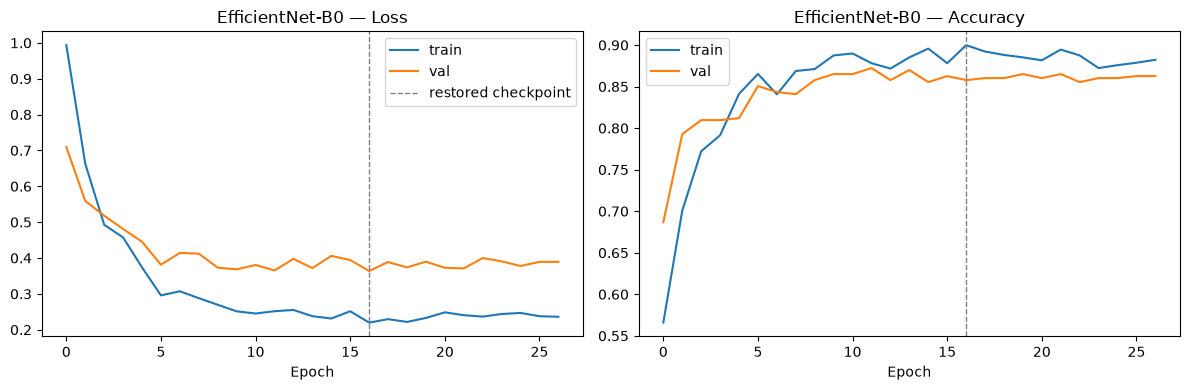

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.864


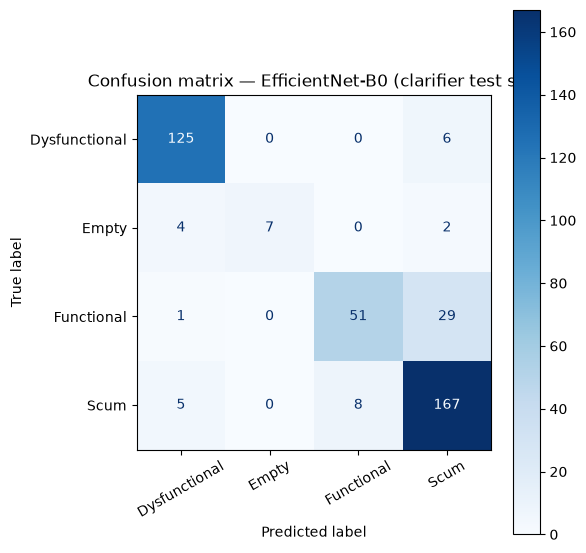

               precision    recall  f1-score   support

Dysfunctional      0.926     0.954     0.940       131
        Empty      1.000     0.538     0.700        13
   Functional      0.864     0.630     0.729        81
         Scum      0.819     0.928     0.870       180

     accuracy                          0.864       405
    macro avg      0.902     0.763     0.810       405
 weighted avg      0.868     0.864     0.859       405



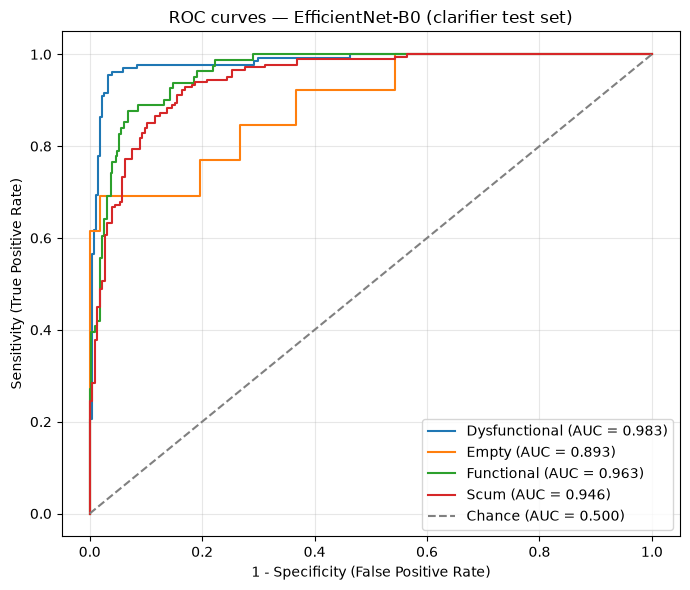

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.983
  Empty          : 0.893
  Functional     : 0.963
  Scum           : 0.946

Mean AUC (over 4/4 classes with test examples): 0.946


(np.float64(0.8641975308641975),
 {'Dysfunctional': 0.9828104975761967,
  'Empty': 0.8928571428571428,
  'Functional': 0.9625438195397044,
  'Scum': 0.9455555555555556})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/clarifier_aug/results_clarifier_efficientnet_b0_NoordelikeWerke.pkl


Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
